# 01 · Data exploration

Inspect the product catalog: schema, group sizes, categories, missing data, sample listings and the leakage-safe split.

> The bundled catalog is **synthetic** (see `data/README.md`).

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import src  # noqa: F401  (sets macOS OpenMP workaround before torch/faiss)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils.config import load_config
config = load_config()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "axes.axisbelow": True})
SAME, DIFF = "#2a78d6", "#eb6834"  # fixed categorical slots 1 and 2

In [2]:
from src.data.dataset import load_catalog_from_config, split_from_config
catalog = load_catalog_from_config(config)
df = catalog.df
df[['product_id', 'title', 'clean_title', 'category', 'label_group']].head(8)

,product_id,title,clean_title,category,label_group
0,P0001,Nordwave Cotton Tee Red Size M,nordwave cotton tee red size m,Fashion,tshirt_red
1,P0002,New Nordwave NO-TS106 T Shirt - Red,new nordwave no-ts106 t shirt - red,Fashion,tshirt_red
2,P0003,[PROMO] T Shirt Nordwave Blue NO-TS113 free sh...,t shirt nordwave blue no-ts113,Fashion,tshirt_blue
3,P0004,nordwave blue t shirt Size M - original,nordwave blue t shirt size m,Fashion,tshirt_blue
4,P0005,NORDWAVE T SHIRT GREEN Size M ready stock,nordwave t shirt green size m,Fashion,tshirt_green
5,P0006,NORDWAVE COTTON T-SHIRT GREEN Size M ready stock,nordwave cotton t-shirt green size m,Fashion,tshirt_green
6,P0007,[PROMO] Cotton Tee Nordwave Green NO-TS120 fre...,cotton tee nordwave green no-ts120,Fashion,tshirt_green
7,P0008,urbankraft black t shirt Size M - original,urbankraft black t shirt size m,Fashion,tshirt_black


In [3]:
print(f'products: {len(df)}  |  label groups: {df.label_group.nunique()}  |  categories: {df.category.nunique()}')
print(f'missing images: {(~df.has_image).sum()}  |  empty titles: {(~df.has_text).sum()}')
print('\nlistings per group:'); print(df.label_group.value_counts().value_counts().sort_index().rename('groups'))
print('\nproducts per category:'); print(df.category.value_counts())

products: 144  |  label groups: 50  |  categories: 6
missing images: 0  |  empty titles: 0

listings per group:
count
2    22
3    12
4    16
Name: groups, dtype: int64

products per category:
category
Fashion           44
Electronics       33
Home & Kitchen    25
Sports            14
Bags              14
Accessories       14
Name: count, dtype: int64


## Sample listings
Same-group listings differ in background, scale, rotation, lighting and title wording. Groups of the same product type that differ only in colour are hard negatives.

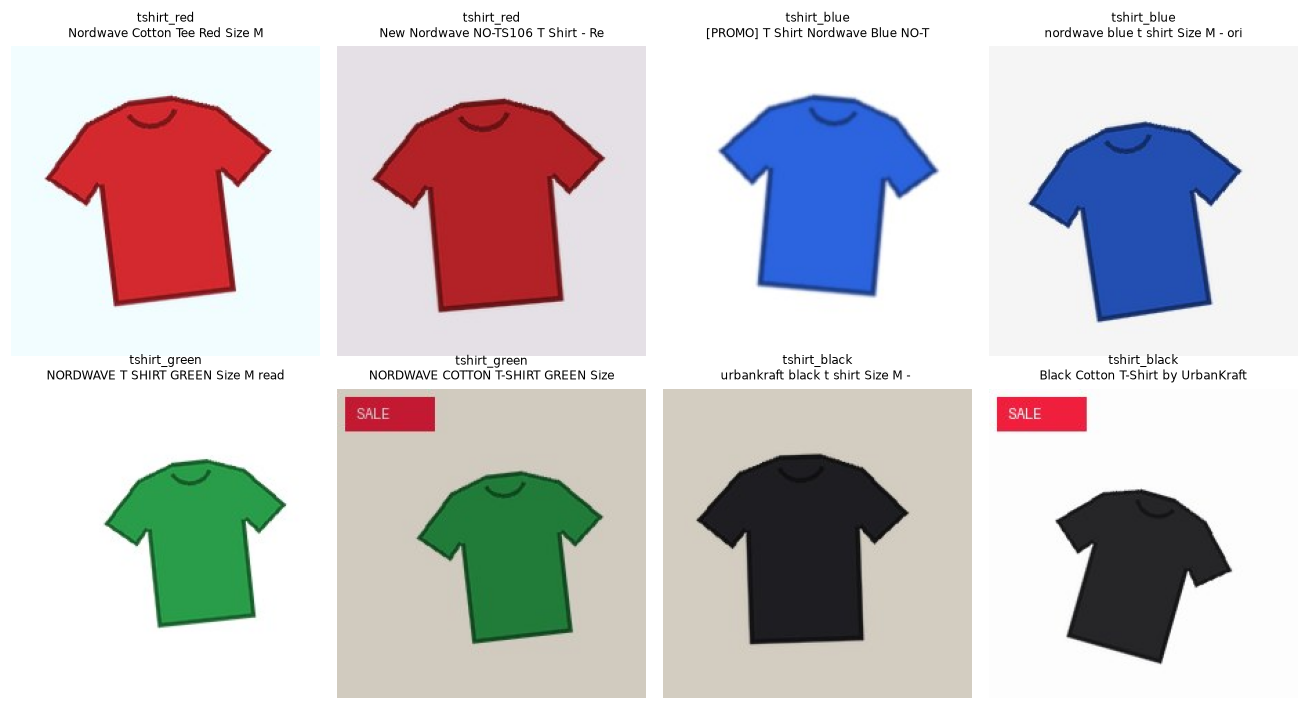

In [4]:
from src.data.preprocessing import load_image
sample = df[df.label_group.str.startswith('tshirt')].groupby('label_group').head(2).head(8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))
for ax, (_, r) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(load_image(r.image_file)); ax.axis('off')
    ax.set_title(f'{r.label_group}\n{r.title[:34]}', fontsize=8)
plt.tight_layout(); plt.show()

## Title cleaning

In [5]:
pd.set_option('display.max_colwidth', 80)
df[['title', 'clean_title']].sample(6, random_state=0)

,title,clean_title
7,urbankraft black t shirt Size M - original,urbankraft black t shirt size m
89,TrekPro Laptop Backpack Red 25L,trekpro laptop backpack red 25l
97,[PROMO] Travel Rucksack TrekPro Green TR-BA122 free shipping,travel rucksack trekpro green tr-ba122
26,brewco yellow mug 350ml - original,brewco yellow mug 350ml
110,[PROMO] Quartz Watch Timely Black TI-WA126 free shipping,quartz watch timely black ti-wa126
128,Nordwave Baseball Cap Red Adjustable,nordwave baseball cap red adjustable


## Group-based split
Listings of one product never appear on both sides, so thresholds and fine-tuned heads are always evaluated on unseen products.

In [6]:
train, test = split_from_config(catalog, config)
g = df.label_group.to_numpy()
print(f'train: {len(train)} rows / {len(set(g[train]))} groups')
print(f'test:  {len(test)} rows / {len(set(g[test]))} groups')
print('groups in both splits:', set(g[train]) & set(g[test]) or 'none')

train: 100 rows / 35 groups
test:  44 rows / 15 groups
groups in both splits: none
